# 评分卡案例

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression as LR

In [2]:
data = pd.read_csv("rankingcard.csv", index_col=0)

In [3]:
data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
data.shape

(150000, 11)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [6]:
# 去重
data.drop_duplicates(inplace=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149391 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149391 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149391 non-null  float64
 2   age                                   149391 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149391 non-null  int64  
 4   DebtRatio                             149391 non-null  float64
 5   MonthlyIncome                         120170 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149391 non-null  int64  
 7   NumberOfTimes90DaysLate               149391 non-null  int64  
 8   NumberRealEstateLoansOrLines          149391 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149391 non-null  int64  
 10  NumberOfDependents                    145563 non-null  float64
dtypes: fl

In [8]:
# 重设索引
data1 = data.reset_index(drop=True)
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149391 entries, 0 to 149390
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149391 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149391 non-null  float64
 2   age                                   149391 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149391 non-null  int64  
 4   DebtRatio                             149391 non-null  float64
 5   MonthlyIncome                         120170 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149391 non-null  int64  
 7   NumberOfTimes90DaysLate               149391 non-null  int64  
 8   NumberRealEstateLoansOrLines          149391 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149391 non-null  int64  
 10  NumberOfDependents                    145563 non-null  float64
dtype

In [9]:
data.index = range(data.shape[0])

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149391 entries, 0 to 149390
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149391 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149391 non-null  float64
 2   age                                   149391 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149391 non-null  int64  
 4   DebtRatio                             149391 non-null  float64
 5   MonthlyIncome                         120170 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149391 non-null  int64  
 7   NumberOfTimes90DaysLate               149391 non-null  int64  
 8   NumberRealEstateLoansOrLines          149391 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149391 non-null  int64  
 10  NumberOfDependents                    145563 non-null  float64
dtype

缺失值填充

In [11]:
# 空值
data.isnull().mean()

SeriousDlqin2yrs                        0.000000
RevolvingUtilizationOfUnsecuredLines    0.000000
age                                     0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
DebtRatio                               0.000000
MonthlyIncome                           0.195601
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
NumberOfDependents                      0.025624
dtype: float64

In [12]:
# 月收入比较重要，不能删除；家属数量的缺失比较少，不重要，可以删除缺失行。
# 均值填充家属数量
data["NumberOfDependents"].fillna(data["NumberOfDependents"].mean(), inplace=True)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149391 entries, 0 to 149390
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149391 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149391 non-null  float64
 2   age                                   149391 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149391 non-null  int64  
 4   DebtRatio                             149391 non-null  float64
 5   MonthlyIncome                         120170 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149391 non-null  int64  
 7   NumberOfTimes90DaysLate               149391 non-null  int64  
 8   NumberRealEstateLoansOrLines          149391 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149391 non-null  int64  
 10  NumberOfDependents                    149391 non-null  float64
dtype

In [18]:
# 对于月收入的填充，猜测是低收入人群，但实际中缺失的原因比较多样，需要和业务人员沟通
# 这里采用随机森林填充。
def fill_missing_rf(X, y, to_fill):
    """使用随机森林填补一个特征的缺失值

    Args:
        X (_type_): 要填补的特征矩阵
        y (_type_): 没有缺失值的标签
        to_fill (_type_): 字符串，要填充的列名
    """
    df = X.copy()
    fill = df.loc[:, to_fill]
    df = pd.concat([df.loc[:, df.columns != to_fill], pd.DataFrame(y)], axis=1)
    
    Ytrain = fill[fill.notnull()]
    Ytest = fill[fill.isnull()]
    Xtrain = df.iloc[Ytrain.index, :]
    Xtest = df.iloc[Ytest.index, :]
    
    from sklearn.ensemble import RandomForestRegressor as rfr
    rfr = rfr(n_estimators=100, n_jobs=-1)
    rfr = rfr.fit(Xtrain, Ytrain)
    Ypredict = rfr.predict(Xtest)
    
    return Ypredict

In [15]:
X = data.iloc[:, 1:]
y = data.iloc[:, 0]
X.shape

(149391, 10)

In [19]:
Ypredict = fill_missing_rf(X, y, "MonthlyIncome")

In [20]:
data.loc[data.loc[:, "MonthlyIncome"].isnull(), "MonthlyIncome"] = Ypredict

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149391 entries, 0 to 149390
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149391 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149391 non-null  float64
 2   age                                   149391 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149391 non-null  int64  
 4   DebtRatio                             149391 non-null  float64
 5   MonthlyIncome                         149391 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149391 non-null  int64  
 7   NumberOfTimes90DaysLate               149391 non-null  int64  
 8   NumberRealEstateLoansOrLines          149391 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149391 non-null  int64  
 10  NumberOfDependents                    149391 non-null  float64
dtype

In [22]:
# 描述性统计，返回特定的分位数
data.describe([0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149391.000000,149391.000000,149391.000000,149391.000000,149391.000000,1.493910e+05,149391.000000,149391.000000,149391.000000,149391.000000,149391.000000
mean,0.066999,6.071087,52.306237,0.393886,354.436740,5.428470e+03,8.480892,0.238120,1.022391,0.212503,0.759863
std,0.250021,250.263672,14.725962,3.852953,2041.843455,1.326070e+04,5.136515,3.826165,1.130196,3.810523,1.101749
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
1%,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
10%,0.000000,0.003199,33.000000,0.000000,0.034991,1.800000e-01,3.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030132,41.000000,0.000000,0.177441,1.800000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154235,52.000000,0.000000,0.368234,4.432000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.556494,63.000000,0.000000,0.875279,7.416000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
90%,0.000000,0.978007,72.000000,1.000000,1275.000000,1.080000e+04,15.000000,0.000000,2.000000,0.000000,2.000000


In [23]:
# 发现有年龄为0的列
(data["age"] == 0).sum()

1

In [24]:
data = data[data["age"] != 0]

In [25]:
data.shape

(149390, 11)

异常值处理

In [26]:
data[data.loc[:, "NumberOfTimes90DaysLate"] > 90]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1732,1,1.0,27,98,0.0,2700.000000,0,98,0,98,0.000000
2285,0,1.0,22,98,0.0,1350.823532,0,98,0,98,0.000000
3883,0,1.0,38,98,12.0,2692.270000,0,98,0,98,0.000000
4416,0,1.0,21,98,0.0,0.000000,0,98,0,98,0.000000
4704,0,1.0,21,98,0.0,2000.000000,0,98,0,98,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
146667,1,1.0,25,98,0.0,2251.806857,0,98,0,98,0.759863
147180,1,1.0,68,98,255.0,8.120000,0,98,0,98,0.000000
148548,1,1.0,24,98,54.0,919.280000,0,98,0,98,0.000000
148634,0,1.0,26,98,0.0,2000.000000,0,98,0,98,0.000000


In [27]:
data.loc[:, "NumberOfTimes90DaysLate"].value_counts()

NumberOfTimes90DaysLate
0     141107
1       5232
2       1555
3        667
4        291
98       220
5        131
6         80
7         38
8         21
9         19
10         8
96         5
11         5
13         4
15         2
14         2
12         2
17         1
Name: count, dtype: int64

In [28]:
# 去除异常值
data = data[data.loc[:, "NumberOfTimes90DaysLate"] < 90]

In [29]:
data.shape

(149165, 11)

In [30]:
data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149165.000000,149165.000000,149165.000000,149165.000000,149165.000000,1.491650e+05,149165.000000,149165.000000,149165.000000,149165.000000,149165.000000
mean,0.066188,6.078770,52.331076,0.246720,354.963542,5.432548e+03,8.493688,0.090725,1.023927,0.065069,0.760325
std,0.248612,250.453111,14.714114,0.698935,2043.344496,1.326989e+04,5.129841,0.486354,1.130350,0.330675,1.102024
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030033,41.000000,0.000000,0.178211,1.800000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.153615,52.000000,0.000000,0.368619,4.443000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.553698,63.000000,0.000000,0.876994,7.420000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,13.000000,329664.000000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149165 entries, 0 to 149390
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149165 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149165 non-null  float64
 2   age                                   149165 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149165 non-null  int64  
 4   DebtRatio                             149165 non-null  float64
 5   MonthlyIncome                         149165 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149165 non-null  int64  
 7   NumberOfTimes90DaysLate               149165 non-null  int64  
 8   NumberRealEstateLoansOrLines          149165 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149165 non-null  int64  
 10  NumberOfDependents                    149165 non-null  float64
dtypes: fl

恢复索引

In [32]:
data.reset_index(drop=True, inplace=True)

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149165 entries, 0 to 149164
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149165 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149165 non-null  float64
 2   age                                   149165 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149165 non-null  int64  
 4   DebtRatio                             149165 non-null  float64
 5   MonthlyIncome                         149165 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149165 non-null  int64  
 7   NumberOfTimes90DaysLate               149165 non-null  int64  
 8   NumberRealEstateLoansOrLines          149165 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149165 non-null  int64  
 10  NumberOfDependents                    149165 non-null  float64
dtype

---

偏态分布处理

In [34]:
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

In [35]:
y.value_counts()

SeriousDlqin2yrs
0    139292
1      9873
Name: count, dtype: int64

In [36]:
sample0 = y.value_counts()[0] / y.shape[0]
sample1 = 1 - sample0
print(sample0, sample1)

0.9338115509670499 0.06618844903295007


In [38]:
# 上采样库
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X, y = sm.fit_resample(X, y)

n_sample_ = X.shape[0]

In [39]:
X.shape

(278584, 10)

In [40]:
sample0_ = y.value_counts()[0] / X.shape[0]
sample1_ = 1 - sample0_
print(sample0_, sample1_)

0.5 0.5


In [41]:
y.value_counts()

SeriousDlqin2yrs
1    139292
0    139292
Name: count, dtype: int64

---

训练集和测试集划分

In [42]:
from sklearn.model_selection import train_test_split
X = pd.DataFrame(X)
y = pd.DataFrame(y)

X_train, X_vali, Y_train, Y_vali = train_test_split(X, y, test_size=0.3, random_state=42)

In [43]:
# 组合训练集的特征矩阵和标签
model_data = pd.concat([Y_train, X_train], axis=1)

In [45]:
model_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
228626,1,0.999845,38,0,0.202286,3919.876814,7,0,0,0,0.969204
77755,0,0.067156,59,0,0.377116,9744.000000,25,0,2,0,0.000000
141145,0,0.030254,51,0,0.615891,3800.000000,16,0,2,0,0.000000
171258,1,0.469502,64,0,4487.780696,0.036803,12,0,1,0,0.000000
126241,0,0.025159,40,0,0.178416,13333.000000,6,0,1,0,0.000000


In [46]:
# columns正常不用调整；index需要重设
model_data.reset_index(drop=True, inplace=True)

In [47]:
vali_data = pd.concat([X_vali, Y_vali], axis=1)
vali_data.reset_index(drop=True, inplace=True)

In [48]:
model_data.to_csv("model_data.csv")
vali_data.to_csv("vali_data.csv")

In [2]:
model_data = pd.read_csv("model_data.csv")
vali_data = pd.read_csv("vali_data.csv")

---

分箱

In [3]:
# 以age为例
model_data["qcut"], updown = pd.qcut(model_data["age"], retbins=True, q=20)
# updown: 每个箱子的上下界
# retbins为True会额外返回以样本索引为索引，被分到的箱子为元素的Series。新列`qcut`的内容为该Series

In [4]:
model_data.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,qcut
0,0,1,0.999845,38,0,0.202286,3919.876814,7,0,0,0,0.969204,"(36.0, 39.0]"
1,1,0,0.067156,59,0,0.377116,9744.000000,25,0,2,0,0.000000,"(58.0, 61.0]"
2,2,0,0.030254,51,0,0.615891,3800.000000,16,0,2,0,0.000000,"(50.0, 52.0]"
3,3,1,0.469502,64,0,4487.780696,0.036803,12,0,1,0,0.000000,"(61.0, 64.0]"
4,4,0,0.025159,40,0,0.178416,13333.000000,6,0,1,0,0.000000,"(39.0, 41.0]"


In [5]:
model_data["qcut"].value_counts()

qcut
(36.0, 39.0]      12727
(20.999, 28.0]    11700
(58.0, 61.0]      11592
(45.0, 47.0]      11119
(48.0, 50.0]      11022
(31.0, 34.0]      10809
(50.0, 52.0]      10543
(43.0, 45.0]      10297
(61.0, 64.0]      10198
(52.0, 54.0]       9784
(39.0, 41.0]       9735
(41.0, 43.0]       9669
(28.0, 31.0]       9514
(74.0, 109.0]      9125
(64.0, 68.0]       8955
(54.0, 56.0]       8728
(68.0, 74.0]       8592
(56.0, 58.0]       7946
(34.0, 36.0]       7468
(47.0, 48.0]       5485
Name: count, dtype: int64

In [6]:
updown

array([ 21.,  28.,  31.,  34.,  36.,  39.,  41.,  43.,  45.,  47.,  48.,
        50.,  52.,  54.,  56.,  58.,  61.,  64.,  68.,  74., 109.])

In [7]:
# 提取每个箱中0的个数
count_y0 = model_data[model_data["SeriousDlqin2yrs"] == 0].groupby(by="qcut").count()["SeriousDlqin2yrs"]
count_y0

qcut
(20.999, 28.0]    4226
(28.0, 31.0]      3558
(31.0, 34.0]      4056
(34.0, 36.0]      2824
(36.0, 39.0]      5126
(39.0, 41.0]      3935
(41.0, 43.0]      4044
(43.0, 45.0]      4407
(45.0, 47.0]      4757
(47.0, 48.0]      2487
(48.0, 50.0]      4933
(50.0, 52.0]      4732
(52.0, 54.0]      4697
(54.0, 56.0]      4660
(56.0, 58.0]      4480
(58.0, 61.0]      6777
(61.0, 64.0]      7005
(64.0, 68.0]      6644
(68.0, 74.0]      6766
(74.0, 109.0]     7754
Name: SeriousDlqin2yrs, dtype: int64

In [8]:
count_y1 = model_data[model_data["SeriousDlqin2yrs"] == 1].groupby(by="qcut").count()["SeriousDlqin2yrs"]
count_y1

qcut
(20.999, 28.0]    7474
(28.0, 31.0]      5956
(31.0, 34.0]      6753
(34.0, 36.0]      4644
(36.0, 39.0]      7601
(39.0, 41.0]      5800
(41.0, 43.0]      5625
(43.0, 45.0]      5890
(45.0, 47.0]      6362
(47.0, 48.0]      2998
(48.0, 50.0]      6089
(50.0, 52.0]      5811
(52.0, 54.0]      5087
(54.0, 56.0]      4068
(56.0, 58.0]      3466
(58.0, 61.0]      4815
(61.0, 64.0]      3193
(64.0, 68.0]      2311
(68.0, 74.0]      1826
(74.0, 109.0]     1371
Name: SeriousDlqin2yrs, dtype: int64

In [36]:
# 每个箱的上界和下界以及箱内的0和1总个数
num_bins = [*zip(updown, updown[1:], count_y0, count_y1)]
num_bins

[(21.0, 28.0, 4226, 7474),
 (28.0, 31.0, 3558, 5956),
 (31.0, 34.0, 4056, 6753),
 (34.0, 36.0, 2824, 4644),
 (36.0, 39.0, 5126, 7601),
 (39.0, 41.0, 3935, 5800),
 (41.0, 43.0, 4044, 5625),
 (43.0, 45.0, 4407, 5890),
 (45.0, 47.0, 4757, 6362),
 (47.0, 48.0, 2487, 2998),
 (48.0, 50.0, 4933, 6089),
 (50.0, 52.0, 4732, 5811),
 (52.0, 54.0, 4697, 5087),
 (54.0, 56.0, 4660, 4068),
 (56.0, 58.0, 4480, 3466),
 (58.0, 61.0, 6777, 4815),
 (61.0, 64.0, 7005, 3193),
 (64.0, 68.0, 6644, 2311),
 (68.0, 74.0, 6766, 1826),
 (74.0, 109.0, 7754, 1371)]

In [10]:
# 确定每个箱中有0和1


In [11]:
# 计算WOE和BAD RATE
columns = ["min", "max", "count_0", "count_1"]
df = pd.DataFrame(num_bins, columns=columns)
df

,min,max,count_0,count_1
0,21.0,28.0,4226,7474
1,28.0,31.0,3558,5956
2,31.0,34.0,4056,6753
3,34.0,36.0,2824,4644
4,36.0,39.0,5126,7601
5,39.0,41.0,3935,5800
6,41.0,43.0,4044,5625
7,43.0,45.0,4407,5890
8,45.0,47.0,4757,6362
9,47.0,48.0,2487,2998


In [ ]:
df["total"] = df.count_0 + df.count_1  # 每个箱中的样本数

In [ ]:
df["percentage"] = df.total / df.total.sum()  # 箱中样本数占总样本数比例

In [14]:
df["bad_rate"] = df.count_1 / df.total

In [15]:
df["good%"] = df.count_0 / df.count_0.sum()

In [16]:
df["bad%"] = df.count_1 / df.count_1.sum()

In [17]:
df["woe"] = np.log(df["good%"] / df["bad%"])

In [18]:
rate = df["good%"] - df["bad%"]
iv = np.sum(rate * df.woe)

In [19]:
iv

0.3606484713598016

In [20]:
def get_woe(num_bins):
    columns = ["min", "max", "count_0", "count_1"]
    
    df = pd.DataFrame(num_bins, columns=columns)
    df["total"] = df.count_0 + df.count_1 
    df["percentage"] = df.total / df.total.sum()
    df["bad_rate"] = df.count_1 / df.total
    df["good%"] = df.count_0 / df.count_0.sum()
    df["bad%"] = df.count_1 / df.count_1.sum()
    df["woe"] = np.log(df["good%"] / df["bad%"])
    
    return df

def get_iv(df):
    rate = df["good%"] - df["bad%"]
    iv = np.sum(rate * df.woe)
    return iv

---

In [21]:
# 相邻组卡方检验
import matplotlib.pyplot as plt
import scipy

In [37]:
num_bins_ = num_bins.copy()

In [38]:
IV = []
axisx = []
# 计算相关度


while len(num_bins_) > 2:
    pvs = []
    for i in range(len(num_bins_) - 1):
        x1 = num_bins_[i][2:]
        x2 = num_bins_[i+1][2:]
        
        p = scipy.stats.chi2_contingency([x1,x2])[1]
        pvs.append(p)
    
    # p值最大的两组合并
    i = pvs.index(max(pvs))
    num_bins_[i:i+2] = [
        (
            num_bins_[i][0],
            num_bins_[i+1][1],
            num_bins_[i][2] + num_bins_[i+1][2],
            num_bins_[i][3] + num_bins_[i+1][3]
        )
    ]
    
    # 计算 IV值
    df = get_woe(num_bins_)
    axisx.append(len(num_bins_))
    IV.append(get_iv(df))
    

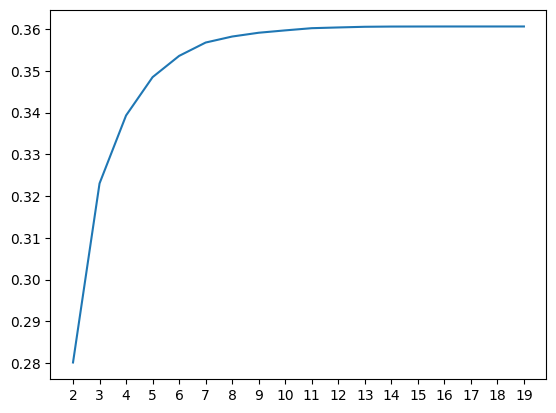

In [26]:
plt.figure()
plt.plot(axisx, IV)
plt.xticks(axisx)
plt.show()

In [27]:
# 根据曲线的变化趋势，箱数为6时的IV值开始骤降，是合适的分箱数
# 封装
def get_bins(num_bins_, n):
    while len(num_bins_) > n:
        pvs = []
        for i in range(len(num_bins_) - 1):
            x1 = num_bins_[i][2:]
            x2 = num_bins_[i+1][2:]
            
            p = scipy.stats.chi2_contingency([x1,x2])[1]
            pvs.append(p)
        
        # p值最大的两组合并
        i = pvs.index(max(pvs))
        num_bins_[i:i+2] = [
            (
                num_bins_[i][0],
                num_bins_[i+1][1],
                num_bins_[i][2] + num_bins_[i+1][2],
                num_bins_[i][3] + num_bins_[i+1][3]
            )
        ]
    return num_bins_

In [40]:
afterbins = get_bins(num_bins, 6)
afterbins

[(21.0, 36.0, 14664, 24827),
 (36.0, 54.0, 39118, 51263),
 (54.0, 61.0, 15917, 12349),
 (61.0, 64.0, 7005, 3193),
 (64.0, 74.0, 13410, 4137),
 (74.0, 109.0, 7754, 1371)]

In [ ]:
woe = get_woe(afterbins)
# woe的变化应该是单调的
woe

,min,max,count_0,count_1,total,percentage,bad_rate,good%,bad%,woe
0,21.0,36.0,14664,24827,39491,0.202510,0.628675,0.149834,0.255580,-0.534003
1,36.0,54.0,39118,51263,90381,0.463473,0.567188,0.399702,0.527723,-0.277853
2,54.0,61.0,15917,12349,28266,0.144948,0.436885,0.162637,0.127126,0.246346
3,61.0,64.0,7005,3193,10198,0.052295,0.313101,0.071576,0.032870,0.778197
4,64.0,74.0,13410,4137,17547,0.089981,0.235767,0.137021,0.042588,1.168563
5,74.0,109.0,7754,1371,9125,0.046793,0.150247,0.079229,0.014114,1.725202


In [68]:
# 根据列名自动分箱
def graphforbestbin(DF, X, Y, n=5, q=20, graph=True):
    """自动分箱函数，基于卡方检验

    Args:
        DF (_type_): 特征矩阵
        X (_type_): 分箱的列名
        Y (_type_): Y的列名
        n (int, optional): 保留分箱个数. Defaults to 5.
        q (int, optional): 初始分箱个数. Defaults to 20.
        graph (bool, optional): 是否画出图像. Defaults to True.
    """
    
    DF = DF[[X,Y]].copy()
    DF["qcut"],bins = pd.qcut(DF[X], retbins=True, q=q,duplicates="drop")
    coount_y0 = DF.loc[DF[Y]==0].groupby(by="qcut").count()[Y]
    coount_y1 = DF.loc[DF[Y]==1].groupby(by="qcut").count()[Y]
    num_bins = [*zip(bins,bins[1:],coount_y0,coount_y1)]
    # print(len(num_bins))
    for i in range(q):
        if 0 in num_bins[0][2:]:
            num_bins[0:2] = [(
                num_bins[0][0],
                num_bins[1][1],
                num_bins[0][2]+num_bins[1][2],
                num_bins[0][3]+num_bins[1][3])]
            continue

        for i in range(len(num_bins)):
            if 0 in num_bins[i][2:]:
                num_bins[i-1:i+1] = [(
                    num_bins[i-1][0],
                    num_bins[i][1],
                    num_bins[i-1][2]+num_bins[i][2],
                    num_bins[i-1][3]+num_bins[i][3])]
                break
        else:  
            break
    def get_woe(num_bins):
        columns = ["min","max","count_0","count_1"]
        df = pd.DataFrame(num_bins,columns=columns)
        df["total"] = df.count_0 + df.count_1
        df["percentage"] = df.total / df.total.sum()
        df["bad_rate"] = df.count_1 / df.total
        df["good%"] = df.count_0/df.count_0.sum()
        df["bad%"] = df.count_1/df.count_1.sum()
        df["woe"] = np.log(df["good%"] / df["bad%"])
        return df
    def get_iv(df):
        rate = df["good%"] - df["bad%"]
        iv = np.sum(rate * df.woe)
        return iv
    IV = []
    axisx = []
    bins_df = []
    while len(num_bins) > n:
        pvs = []
        for i in range(len(num_bins)-1):
            x1 = num_bins[i][2:]
            x2 = num_bins[i+1][2:]
            pv = scipy.stats.chi2_contingency([x1,x2])[1]
            pvs.append(pv)
        i = pvs.index(max(pvs))
        num_bins[i:i+2] = [(
            num_bins[i][0],
            num_bins[i+1][1],
            num_bins[i][2]+num_bins[i+1][2],
            num_bins[i][3]+num_bins[i+1][3])]
        bins_df = pd.DataFrame(get_woe(num_bins))
        axisx.append(len(num_bins))
        IV.append(get_iv(bins_df))
    if graph:
        plt.figure()
        plt.plot(axisx,IV) 
        plt.xticks(axisx)
        plt.xlabel("number of box")
        plt.ylabel("IV")
        plt.show() 
    
    return bins_df

In [51]:
model_data.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'qcut'],
      dtype='object')

RevolvingUtilizationOfUnsecuredLines
20


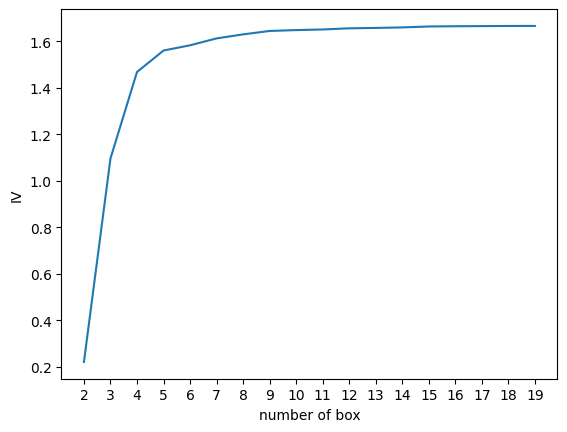

age
20


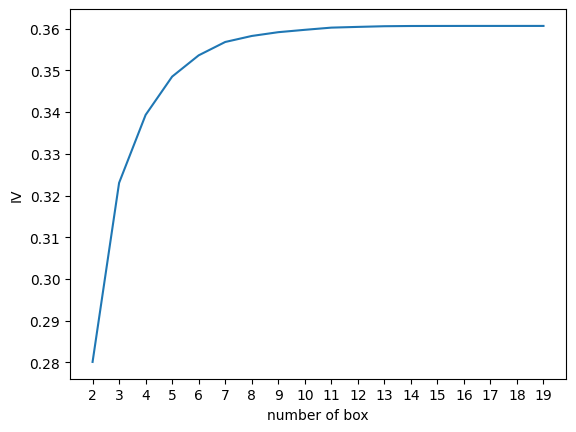

NumberOfTime30-59DaysPastDueNotWorse
3


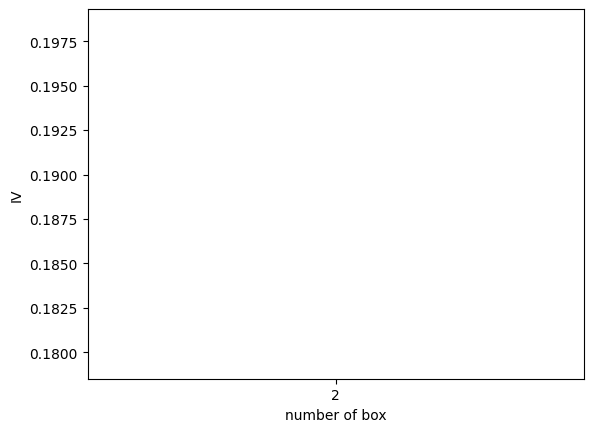

DebtRatio
20


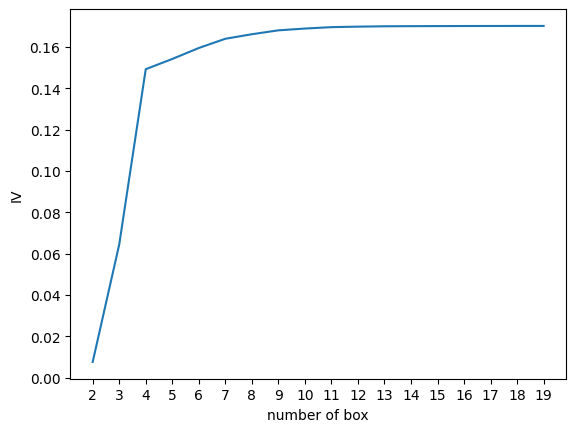

MonthlyIncome
20


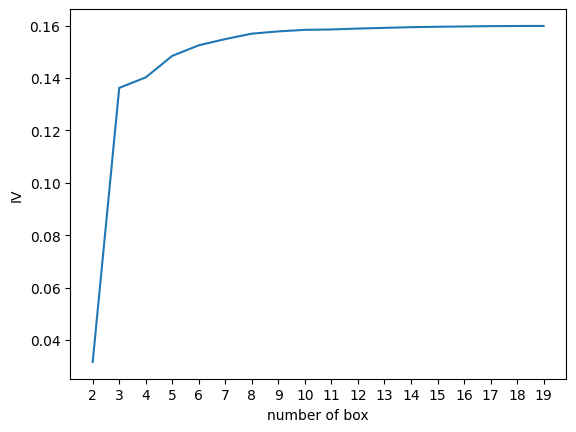

NumberOfOpenCreditLinesAndLoans
16


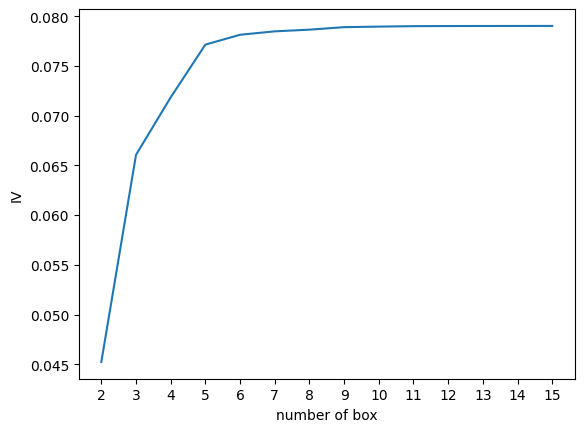

NumberOfTimes90DaysLate
3


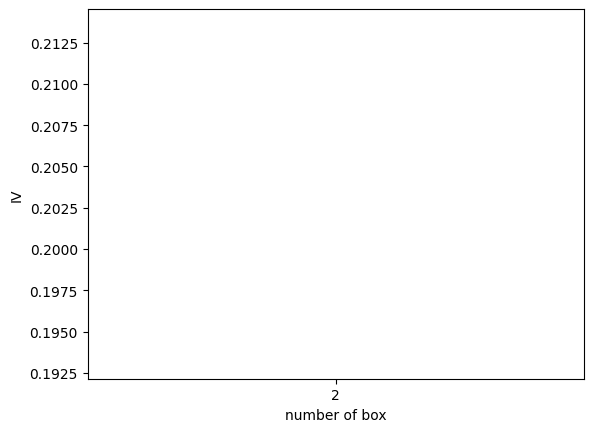

NumberRealEstateLoansOrLines
4


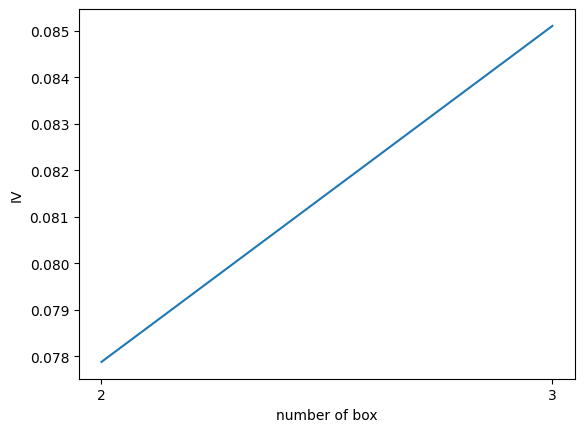

NumberOfTime60-89DaysPastDueNotWorse
2


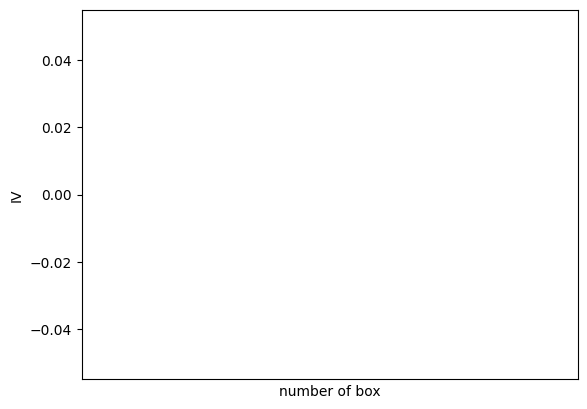

NumberOfDependents
10


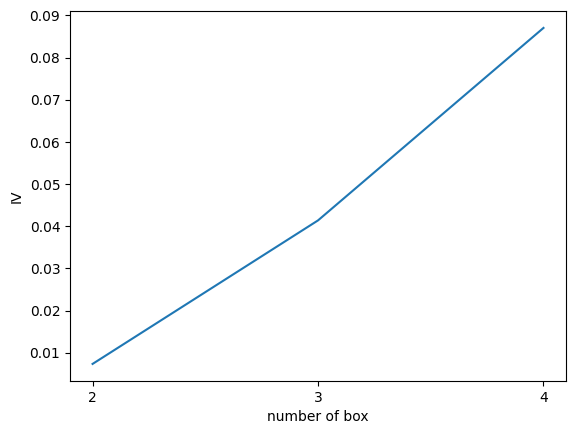

In [52]:
for i in model_data.columns[2:-1]:
    print(i)
    graphforbestbin(model_data, i, "SeriousDlqin2yrs", n=2, q=20)


In [76]:
auto_col_bins = {"RevolvingUtilizationOfUnsecuredLines":6,
                    "age":5,
                    "DebtRatio":4,
                    "MonthlyIncome":3,
                    "NumberOfOpenCreditLinesAndLoans" : 5
                    }

#不能使用自动分箱的变量
hand_bins = {"NumberOfTime30-59DaysPastDueNotWorse": [0, 1,2, 13]
                , "NumberOfTimes90DaysLate": [0, 1, 2, 17]
                , "NumberRealEstateLoansOrLines": [0, 1,2, 4, 54]
                , "NumberOfTime60-89DaysPastDueNotWorse": [0, 1,2, 8]
                , "NumberOfDependents": [0, 1, 2, 3]}

#保证区间覆盖使用np.inf替换最大值，用-np.inf替换最小值
hand_bins = {k: [-np.inf,*v[:-1], np.inf] for k,v in hand_bins.items()}

In [77]:
hand_bins

{'NumberOfTime30-59DaysPastDueNotWorse': [-inf, 0, 1, 2, inf],
 'NumberOfTimes90DaysLate': [-inf, 0, 1, 2, inf],
 'NumberRealEstateLoansOrLines': [-inf, 0, 1, 2, 4, inf],
 'NumberOfTime60-89DaysPastDueNotWorse': [-inf, 0, 1, 2, inf],
 'NumberOfDependents': [-inf, 0, 1, 2, inf]}

In [78]:
model_data.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'qcut'],
      dtype='object')

In [79]:
bins_of_col = {}

for col in auto_col_bins:
    # print(col)
    bins_df = graphforbestbin(model_data, col,
                            "SeriousDlqin2yrs",
                            n=auto_col_bins[col],
                            q=20,
                            graph=False)
    
    bins_list = sorted(set(bins_df["min"]).union(bins_df["max"]))
    
    bins_list[0], bins_list[-1] = -np.inf, np.inf
    bins_of_col[col] = bins_list

In [80]:
bins_of_col

{'RevolvingUtilizationOfUnsecuredLines': [-inf,
  0.033872158000000006,
  0.15239200230000002,
  0.4636660439232757,
  0.9828274107053198,
  0.9999999,
  inf],
 'age': [-inf, 36.0, 54.0, 61.0, 74.0, inf],
 'DebtRatio': [-inf, 0.0173238052, 0.40026382349669554, 1.49905853893462, inf],
 'MonthlyIncome': [-inf, 0.10051704242431528, 6166.381935187823, inf],
 'NumberOfOpenCreditLinesAndLoans': [-inf, 1.0, 3.0, 5.0, 17.0, inf]}

In [81]:
bins_of_col.update(hand_bins)

In [82]:
bins_of_col

{'RevolvingUtilizationOfUnsecuredLines': [-inf,
  0.033872158000000006,
  0.15239200230000002,
  0.4636660439232757,
  0.9828274107053198,
  0.9999999,
  inf],
 'age': [-inf, 36.0, 54.0, 61.0, 74.0, inf],
 'DebtRatio': [-inf, 0.0173238052, 0.40026382349669554, 1.49905853893462, inf],
 'MonthlyIncome': [-inf, 0.10051704242431528, 6166.381935187823, inf],
 'NumberOfOpenCreditLinesAndLoans': [-inf, 1.0, 3.0, 5.0, 17.0, inf],
 'NumberOfTime30-59DaysPastDueNotWorse': [-inf, 0, 1, 2, inf],
 'NumberOfTimes90DaysLate': [-inf, 0, 1, 2, inf],
 'NumberRealEstateLoansOrLines': [-inf, 0, 1, 2, 4, inf],
 'NumberOfTime60-89DaysPastDueNotWorse': [-inf, 0, 1, 2, inf],
 'NumberOfDependents': [-inf, 0, 1, 2, inf]}

In [83]:
# 计算各箱的WOE，映射到数据中
data = model_data.copy()



In [84]:
def get_woe(df, col, y, bins):
    df = df[[col,y]].copy()
    df["cut"] = pd.cut(df[col], bins)
    # 每箱的0和1，unstack将每组的0和1变为两列
    bins_df = df.groupby("cut")[y].value_counts().unstack()
    
    woe = bins_df["woe"] = np.log((bins_df[0] / bins_df[0].sum()) / (bins_df[1] / bins_df[1].sum()))
    
    return woe

In [85]:
woeall = {}

for col in bins_of_col:
    woeall[col] = get_woe(model_data, col, "SeriousDlqin2yrs", bins_of_col[col])
    

In [ ]:
# 每个箱以及对应的woe值
woeall["DebtRatio"]

cut
(-inf, 0.0173]    1.520864
(0.0173, 0.4]     0.037508
(0.4, 1.499]     -0.390673
(1.499, inf]      0.175288
dtype: float64

In [90]:
# 映射原始数据
model_woe = pd.DataFrame(index=model_data.index)

In [91]:
for col in bins_of_col:
    model_woe[col] = pd.cut(model_data[col], bins_of_col[col]).map(woeall[col])
    
model_woe["SeriousDlqin2yrs"] = model_data["SeriousDlqin2yrs"]

In [92]:
model_woe.head()

,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
0,-0.504655,-0.277853,0.037508,-0.218129,0.131947,0.356888,0.236504,-0.398123,0.123462,-0.516116,1
1,1.514957,0.246346,0.037508,0.272941,0.488906,0.356888,0.236504,0.627989,0.123462,0.654458,0
2,2.648267,-0.277853,-0.390673,-0.218129,0.131947,0.356888,0.236504,0.627989,0.123462,0.654458,0
3,-1.070603,1.016828,0.175288,1.388599,0.131947,0.356888,0.236504,0.197907,0.123462,0.654458,1
4,2.648267,-0.277853,0.037508,0.272941,0.131947,0.356888,0.236504,0.197907,0.123462,0.654458,0


In [93]:
vali_woe = pd.DataFrame(index=vali_data.index)

In [94]:
for col in bins_of_col:
    vali_woe[col] = pd.cut(vali_data[col], bins_of_col[col]).map(woeall[col])
    

In [96]:
vali_x = vali_woe
vali_y = vali_data["SeriousDlqin2yrs"]

In [98]:
x = model_woe.iloc[:, :-1]
y = model_woe.iloc[:, -1]

In [99]:
# 逻辑回归
from sklearn.linear_model import LogisticRegression as LR

In [100]:
lr = LR().fit(x, y)
lr.score(vali_x, vali_y)

0.7847109217957309

In [107]:
c_1 = np.linspace(0.01, 1, 20)
c_2 = np.linspace(0.01, 0.2, 20)

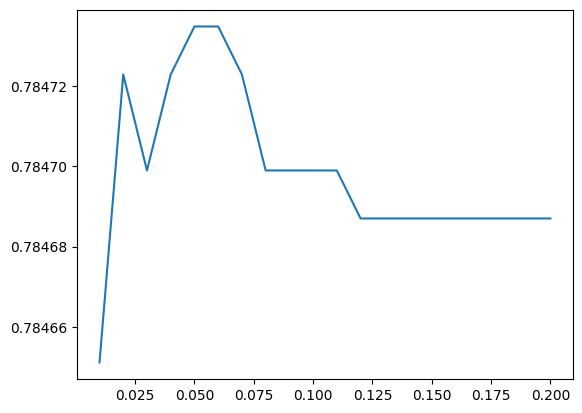

In [111]:
score = []
for i in c_2:
    lr = LR(solver="liblinear", C=i).fit(x,y)
    score.append(lr.score(vali_x, vali_y))
    
plt.figure()
plt.plot(c_2, score)
plt.show()

In [109]:
# 模型效果受限，调max_iter
lr.n_iter_

array([5], dtype=int32)

In [121]:
score1 = []
for i in range( 1, 5):
    lr = LR(solver="liblinear", C=0.05, max_iter=i).fit(x,y)
    score1.append(lr.score(vali_x, vali_y))
    


d:\envs\scikit_learn\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\envs\scikit_learn\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\envs\scikit_learn\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\envs\scikit_learn\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


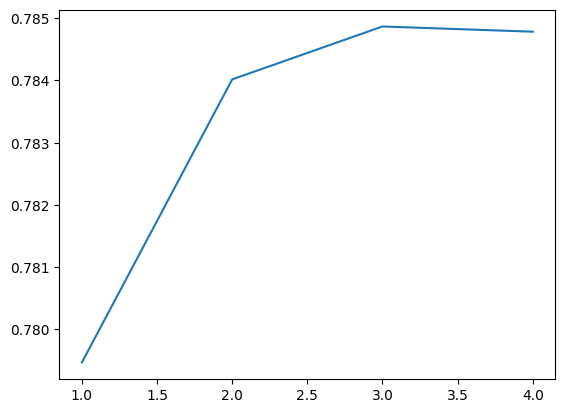

In [122]:
plt.figure()
plt.plot([1,2,3,4], score1)
plt.show()

---

In [125]:
# 画图ROC曲线
import scikitplot as skplt

<Axes: title={'center': 'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

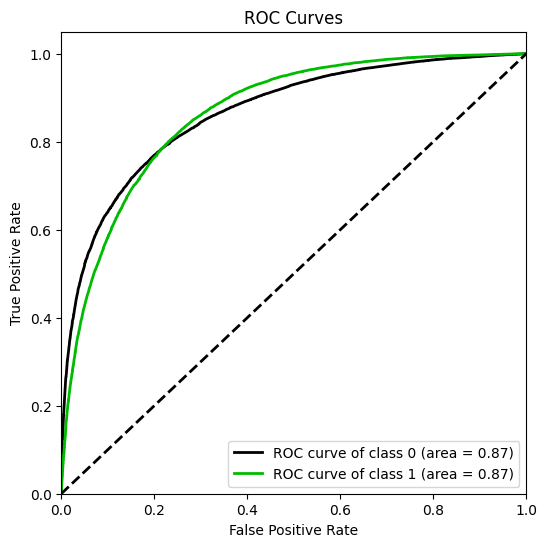

In [126]:
vali_proba_df = pd.DataFrame(lr.predict_proba(vali_x))
skplt.metrics.plot_roc(vali_y, vali_proba_df, plot_micro=False, figsize=(6,6), plot_macro=False)

模型捕捉少数类的水平越高，误判多数类的可能性变化
曲线下方的为AUC面积，面积越大，模型效果越好

---

In [127]:
# 评分卡中的分数计算公式为 score = A - B * log(odds)
# 由前面可知log(odds)即 theta.T * x 
B = 20/np.log(2)
A = 600 + B * np.log(1/60)
B, A

(28.85390081777927, 481.8621880878296)

In [129]:
base_score = A - B * lr.intercept_
base_score

array([482.04068154])

In [133]:
woeall.keys()

dict_keys(['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'])

In [134]:
# 再计算每个箱对应的分数
score_age = woeall["age"] * (-B * lr.coef_[0][1])
score_age

cut
(-inf, 36.0]    -4.437640
(36.0, 54.0]    -2.308998
(54.0, 61.0]     2.047173
(61.0, 74.0]     8.449989
(74.0, inf]     14.336680
dtype: float64

In [141]:
file = "score_data.csv"

with open(file, "w") as fdata:
    fdata.write(f"base_score:{base_score[0]}\n")
    
for i, col in enumerate(x.columns):
    score = woeall[col] * (- B * lr.coef_[0][i])
    score.name = "Score"
    score.index.name = col
    score.to_csv(file, header=True, mode="a")